In [ ]:
# ── CELL 1 : Installs & Imports ─────────────────────────────────────────────
!pip install -q tensorflow scikit-learn matplotlib seaborn

import os, json, pickle, random, urllib.request, tarfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TF version : 2.20.0
GPU        : []


In [ ]:
# ── CELL 2 : Mount Drive & Folders ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ICT4442_Project'

DRIVE = {
    'shared'  : f'{BASE}/shared',        # tokenizer saved here by MLP
    'weights' : f'{BASE}/BiLSTM/weights',
    'history' : f'{BASE}/BiLSTM/history',
    'results' : f'{BASE}/BiLSTM/results',
}
for d in DRIVE.values():
    os.makedirs(d, exist_ok=True)

LOCAL = {
    'data'  : '/content/data',
    'plots' : '/content/plots/BiLSTM',
}
for d in LOCAL.values():
    os.makedirs(d, exist_ok=True)

# ── Must match MLP and CNN exactly ───────────────────────────────────────────
VOCAB_SIZE = 20000
MAX_LEN    = 512       # same as MLP and CNN
EMBED_DIM  = 128

print(f"VOCAB_SIZE={VOCAB_SIZE}  MAX_LEN={MAX_LEN}  EMBED_DIM={EMBED_DIM}")
print("Folders ready.")

Mounted at /content/drive
VOCAB_SIZE=20000  MAX_LEN=512  EMBED_DIM=128
Folders ready.


In [ ]:
# ── CELL 3 : Dataset + Tokenizer + Sequences ────────────────────────────────
DATA_PATH = '/content/data/aclImdb'

if not os.path.exists(DATA_PATH):
    print("Downloading IMDb dataset (~84 MB)...")
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    urllib.request.urlretrieve(url, '/content/data/aclImdb_v1.tar.gz')
    print("Extracting...")
    with tarfile.open('/content/data/aclImdb_v1.tar.gz', 'r:gz') as t:
        t.extractall('/content/data/')
    os.remove('/content/data/aclImdb_v1.tar.gz')
    print("Done.")
else:
    print("Dataset already local — skipping download.")

def load_split(split_dir):
    texts, labels = [], []
    for label_idx, sentiment in enumerate(['neg', 'pos']):
        folder = os.path.join(split_dir, sentiment)
        for fname in sorted(os.listdir(folder)):
            if fname.endswith('.txt'):
                with open(os.path.join(folder, fname),
                          encoding='utf-8') as f:
                    texts.append(f.read())
                labels.append(label_idx)
    return texts, labels

print("Loading splits...")
train_texts_full, train_labels_full = load_split(f'{DATA_PATH}/train')
test_texts,       test_labels_raw   = load_split(f'{DATA_PATH}/test')

# ── Same split as MLP and CNN — SEED and test_size must not change ───────────
train_texts, val_texts, train_labels_raw, val_labels_raw = train_test_split(
    train_texts_full, train_labels_full,
    test_size=5000, random_state=SEED, stratify=train_labels_full
)

train_labels = np.array(train_labels_raw)
val_labels   = np.array(val_labels_raw)
test_labels  = np.array(test_labels_raw)

print(f"Train : {len(train_texts):,}  "
      f"Val : {len(val_texts):,}  "
      f"Test : {len(test_texts):,}")

# Load tokenizer from Drive — same vocab as MLP and CNN
TOKENIZER_PATH = f"{DRIVE['shared']}/tokenizer.pkl"
with open(TOKENIZER_PATH, 'rb') as f:
    tokenizer = pickle.load(f)
print("Tokenizer loaded from Drive.")

# Build sequences locally
print("Building sequences (MAX_LEN=512)...")
X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_texts),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_val = pad_sequences(
    tokenizer.texts_to_sequences(val_texts),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_texts),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print("Sequences built locally — not saved to Drive.")

Extracting...


/tmp/ipykernel_1393/1462838966.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall('/content/data/')


Done.
Loading splits...
Train : 20,000  Val : 5,000  Test : 25,000
Tokenizer loaded from Drive.
Building sequences (MAX_LEN=512)...
X_train : (20000, 512)
X_val   : (5000, 512)
X_test  : (25000, 512)
Sequences built locally — not saved to Drive.


In [ ]:
# ── CELL 4 : Build BiLSTM ────────────────────────────────────────────────────
# Architecture decisions:
#   - SpatialDropout1D(0.3) after embedding — same rate as final CNN,
#     same reason: 2.56M embedding params need regularization
#   - Single Bidirectional LSTM(64) — reads sequence forward + backward,
#     output is 128 features (64 forward + 64 backward concatenated)
#   - recurrent_dropout=0.2 — regularizes the recurrent connections
#     specifically, separate from the output dropout
#   - Single Dense(64) + L2 — matches MLP and CNN head design
#   - Dropout(0.4) then Dropout(0.3) — same as MLP and CNN head
#   - One LSTM layer only — stacking would add capacity and risk
#     more overfitting; single layer is cleaner for a baseline BiLSTM

def build_bilstm():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBED_DIM,
            mask_zero=True,
            name='embedding'
        ),
        SpatialDropout1D(0.3, name='spatial_dropout'),
        Bidirectional(
            LSTM(
                64,
                dropout=0.3,
                recurrent_dropout=0.2,
            ),
            name='bilstm'
        ),
        Dense(
            64,
            activation='relu',
            kernel_regularizer=l2(1e-4),
            name='dense_1'
        ),
        Dropout(0.4, name='dropout_1'),
        Dense(1, activation='sigmoid', name='output'),
    ], name='BiLSTM')

    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.build(input_shape=(None, MAX_LEN))
    return model

model = build_bilstm()
model.summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 512, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 512, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── CELL 5 : Train BiLSTM ────────────────────────────────────────────────────
# NOTE: BiLSTM is sequential and cannot parallelise as well as CNN.
# Each epoch will take longer than MLP or CNN. Be patient.
# Expected: 5-8 min per epoch. Total: 45 min - 1.5 hrs depending on
# early stopping.

CHECKPOINT = f"{DRIVE['weights']}/bilstm_best.keras"
BATCH_SIZE = 64
MAX_EPOCHS = 20

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
]

print("Starting BiLSTM training — this will take a while...\n")
history = model.fit(
    X_train, train_labels,
    validation_data=(X_val, val_labels),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# Save full history to Drive immediately
history_data = {
    'model'         : 'BiLSTM',
    'max_len'       : MAX_LEN,
    'epochs_run'    : len(history.history['loss']),
    'train_loss'    : history.history['loss'],
    'val_loss'      : history.history['val_loss'],
    'train_accuracy': history.history['accuracy'],
    'val_accuracy'  : history.history['val_accuracy'],
    'lr'            : [float(x) for x in
                       history.history.get('learning_rate', [])],
}
with open(f"{DRIVE['history']}/bilstm_history.json", 'w') as f:
    json.dump(history_data, f, indent=2)

best_epoch = np.argmin(history_data['val_loss']) + 1
print(f"\nEpochs run    : {history_data['epochs_run']}")
print(f"Best epoch    : {best_epoch}")
print(f"Best val_loss : {min(history_data['val_loss']):.4f}")
print(f"Best val_acc  : {max(history_data['val_accuracy']):.4f}")
print("History saved to Drive.")

Starting BiLSTM training — this will take a while...

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6328 - loss: 0.6284
Epoch 1: val_loss improved from None to 0.34824, saving model to /content/drive/MyDrive/ICT4442_Project/BiLSTM/weights/bilstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ICT4442_Project/BiLSTM/weights/bilstm_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 709s 2s/step - accuracy: 0.7333 - loss: 0.5301 - val_accuracy: 0.8532 - val_loss: 0.3482 - learning_rate: 5.0000e-04
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8674 - loss: 0.3550
Epoch 2: val_loss improved from 0.34824 to 0.31426, saving model to /content/drive/MyDrive/ICT4442_Project/BiLSTM/weights/bilstm_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ICT4442_Project/BiLSTM/weights/bilstm_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.8835 - loss: 0.3141 - val_accuracy: 0.8628 - val_loss: 0.3143 - learning_rate: 5.00

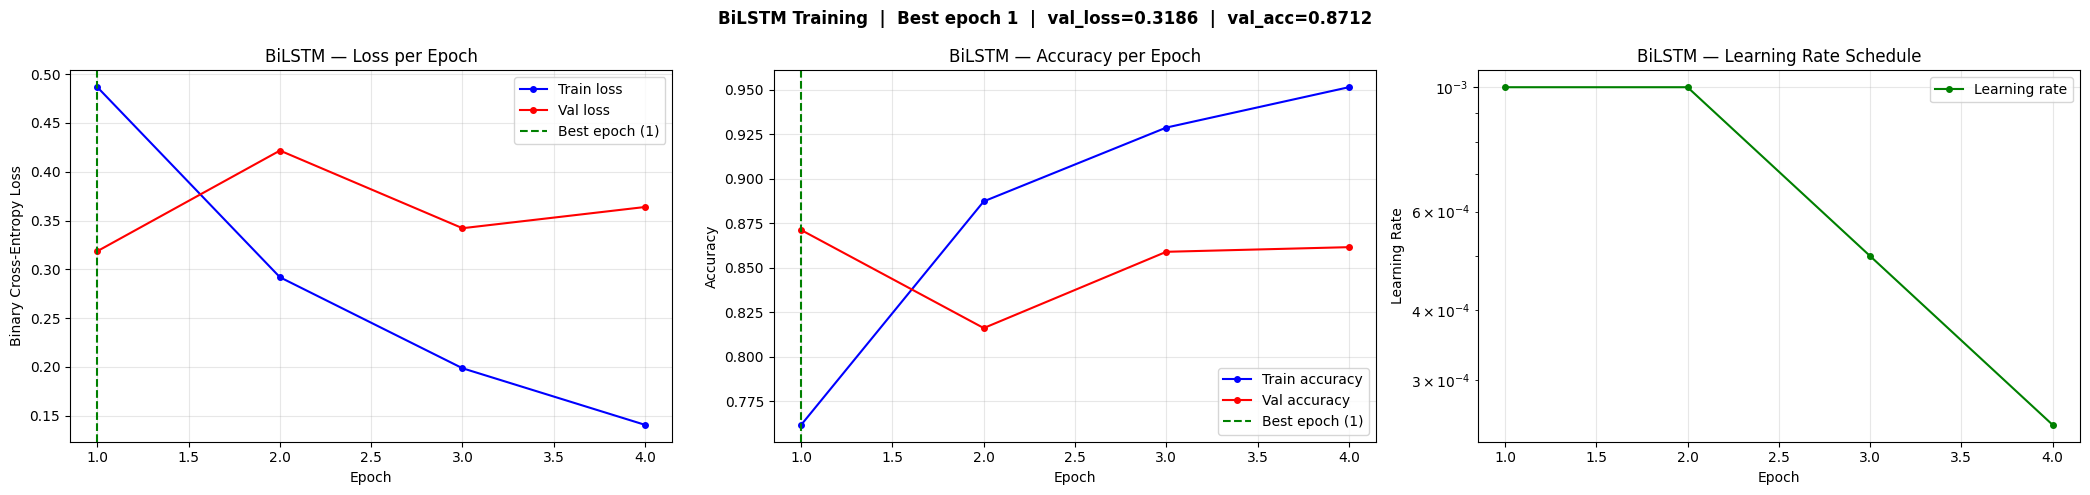

Training curves saved locally.


In [ ]:
# ── CELL 6 : Training Curves ─────────────────────────────────────────────────
# To reload without retraining:
# with open(f"{DRIVE['history']}/bilstm_history.json") as f:
#     history_data = json.load(f)

epochs = range(1, history_data['epochs_run'] + 1)
best_e = np.argmin(history_data['val_loss']) + 1
has_lr = len(history_data['lr']) > 0

n_cols = 3 if has_lr else 2
fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 5))

axes[0].plot(epochs, history_data['train_loss'], 'b-o',
             markersize=4, label='Train loss')
axes[0].plot(epochs, history_data['val_loss'],   'r-o',
             markersize=4, label='Val loss')
axes[0].axvline(best_e, color='green', linestyle='--',
                label=f'Best epoch ({best_e})')
axes[0].set_title('BiLSTM — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_data['train_accuracy'], 'b-o',
             markersize=4, label='Train accuracy')
axes[1].plot(epochs, history_data['val_accuracy'],   'r-o',
             markersize=4, label='Val accuracy')
axes[1].axvline(best_e, color='green', linestyle='--',
                label=f'Best epoch ({best_e})')
axes[1].set_title('BiLSTM — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

if has_lr:
    axes[2].plot(epochs, history_data['lr'], 'g-o',
                 markersize=4, label='Learning rate')
    axes[2].set_title('BiLSTM — Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_yscale('log')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

plt.suptitle(
    f"BiLSTM Training  |  Best epoch {best_e}  |  "
    f"val_loss={history_data['val_loss'][best_e-1]:.4f}  |  "
    f"val_acc={history_data['val_accuracy'][best_e-1]:.4f}",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/01_bilstm_training_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved locally.")

In [ ]:
# ── CELL 7 : Validation Evaluation ───────────────────────────────────────────
val_probs = model.predict(X_val, batch_size=64, verbose=0).flatten()
val_preds = (val_probs >= 0.5).astype(int)

val_metrics = {
    'model'    : 'BiLSTM',
    'split'    : 'validation',
    'max_len'  : MAX_LEN,
    'accuracy' : float(accuracy_score(val_labels,  val_preds)),
    'precision': float(precision_score(val_labels, val_preds)),
    'recall'   : float(recall_score(val_labels,    val_preds)),
    'f1'       : float(f1_score(val_labels,        val_preds)),
    'auc'      : float(roc_auc_score(val_labels,   val_probs)),
}

print("── Validation Metrics ──────────────────────")
for k, v in val_metrics.items():
    if k not in ('model', 'split', 'max_len'):
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(
    val_labels, val_preds,
    target_names=['Negative', 'Positive']
))

fpr, tpr, _ = roc_curve(val_labels, val_probs)
roc_val = {
    'fpr': fpr.tolist(),
    'tpr': tpr.tolist(),
    'auc': val_metrics['auc']
}

np.save(f"{DRIVE['results']}/val_probs.npy",    val_probs)
np.save(f"{DRIVE['results']}/val_preds.npy",    val_preds)
with open(f"{DRIVE['results']}/val_metrics.json", 'w') as f:
    json.dump(val_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_val.json", 'w') as f:
    json.dump(roc_val, f)
print("Val results saved to Drive.")

── Validation Metrics ──────────────────────
  accuracy    : 0.8712
  precision   : 0.8841
  recall      : 0.8544
  f1          : 0.8690
  auc         : 0.9404

              precision    recall  f1-score   support

    Negative       0.86      0.89      0.87      2500
    Positive       0.88      0.85      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000

Val results saved to Drive.


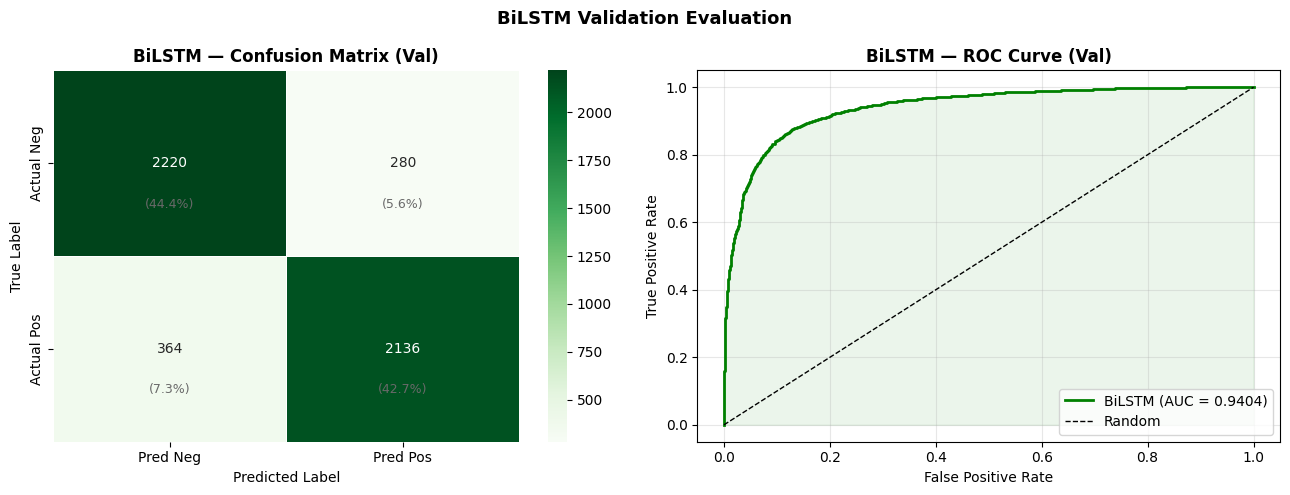

In [ ]:
# ── CELL 8 : Confusion Matrix + ROC — Validation ────────────────────────────
# To re-plot without retraining:
# val_probs = np.load(f"{DRIVE['results']}/val_probs.npy")
# val_preds = np.load(f"{DRIVE['results']}/val_preds.npy")
# with open(f"{DRIVE['results']}/roc_val.json") as f:
#     roc_val = json.load(f)

cm = confusion_matrix(val_labels, val_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
    xticklabels=['Pred Neg', 'Pred Pos'],
    yticklabels=['Actual Neg', 'Actual Pos'],
    linewidths=0.5
)
for i in range(2):
    for j in range(2):
        axes[0].text(
            j + 0.5, i + 0.72,
            f"({cm[i,j] / cm.sum() * 100:.1f}%)",
            ha='center', va='center',
            fontsize=9, color='dimgray'
        )
axes[0].set_title('BiLSTM — Confusion Matrix (Val)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(roc_val['fpr'], roc_val['tpr'],
             color='green', lw=2,
             label=f"BiLSTM (AUC = {roc_val['auc']:.4f})")
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(roc_val['fpr'], roc_val['tpr'],
                     alpha=0.08, color='green')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('BiLSTM — ROC Curve (Val)', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.suptitle('BiLSTM Validation Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/02_bilstm_val_cm_roc.png",
            dpi=150, bbox_inches='tight')
plt.show()

── TEST RESULTS ───────────────────────────
  accuracy    : 0.8062
  precision   : 0.7622
  recall      : 0.8899
  f1          : 0.8211
  auc         : 0.8786

              precision    recall  f1-score   support

    Negative       0.87      0.72      0.79     12500
    Positive       0.76      0.89      0.82     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.80     25000
weighted avg       0.81      0.81      0.80     25000



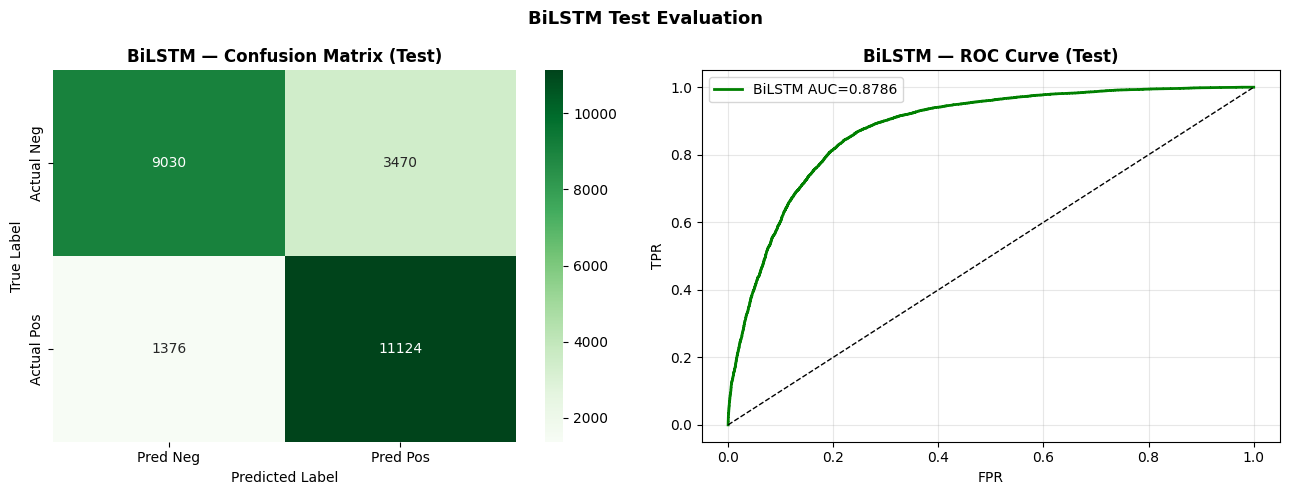

All test results saved to Drive.


In [ ]:
# ── CELL 9 : TEST SET EVALUATION ─────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════════╗
# ║  ONLY RUN AFTER ALL FOUR MODELS ARE FULLY FINALIZED.            ║
# ║  The test set must not influence any further decisions.         ║
# ╚══════════════════════════════════════════════════════════════════╝

test_probs = model.predict(X_test, batch_size=64, verbose=0).flatten()
test_preds = (test_probs >= 0.5).astype(int)

test_metrics = {
    'model'    : 'BiLSTM',
    'split'    : 'test',
    'max_len'  : MAX_LEN,
    'accuracy' : float(accuracy_score(test_labels,  test_preds)),
    'precision': float(precision_score(test_labels, test_preds)),
    'recall'   : float(recall_score(test_labels,    test_preds)),
    'f1'       : float(f1_score(test_labels,        test_preds)),
    'auc'      : float(roc_auc_score(test_labels,   test_probs)),
}

print("── TEST RESULTS ───────────────────────────")
for k, v in test_metrics.items():
    if k not in ('model', 'split', 'max_len'):
        print(f"  {k:12s}: {v:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=['Negative', 'Positive']
))

fpr_t, tpr_t, _ = roc_curve(test_labels, test_probs)
roc_test = {
    'fpr': fpr_t.tolist(),
    'tpr': tpr_t.tolist(),
    'auc': test_metrics['auc']
}

np.save(f"{DRIVE['results']}/test_probs.npy", test_probs)
np.save(f"{DRIVE['results']}/test_preds.npy", test_preds)
with open(f"{DRIVE['results']}/test_metrics.json", 'w') as f:
    json.dump(test_metrics, f, indent=2)
with open(f"{DRIVE['results']}/roc_test.json", 'w') as f:
    json.dump(roc_test, f)

cm_t = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm_t, annot=True, fmt='d', cmap='Greens', ax=axes[0],
    xticklabels=['Pred Neg', 'Pred Pos'],
    yticklabels=['Actual Neg', 'Actual Pos']
)
axes[0].set_title('BiLSTM — Confusion Matrix (Test)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(fpr_t, tpr_t, color='green', lw=2,
             label=f"BiLSTM AUC={test_metrics['auc']:.4f}")
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('BiLSTM — ROC Curve (Test)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('BiLSTM Test Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/03_bilstm_test_cm_roc.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("All test results saved to Drive.")

Correct : 20,154  (80.6%)
Wrong   : 4,846   (19.4%)


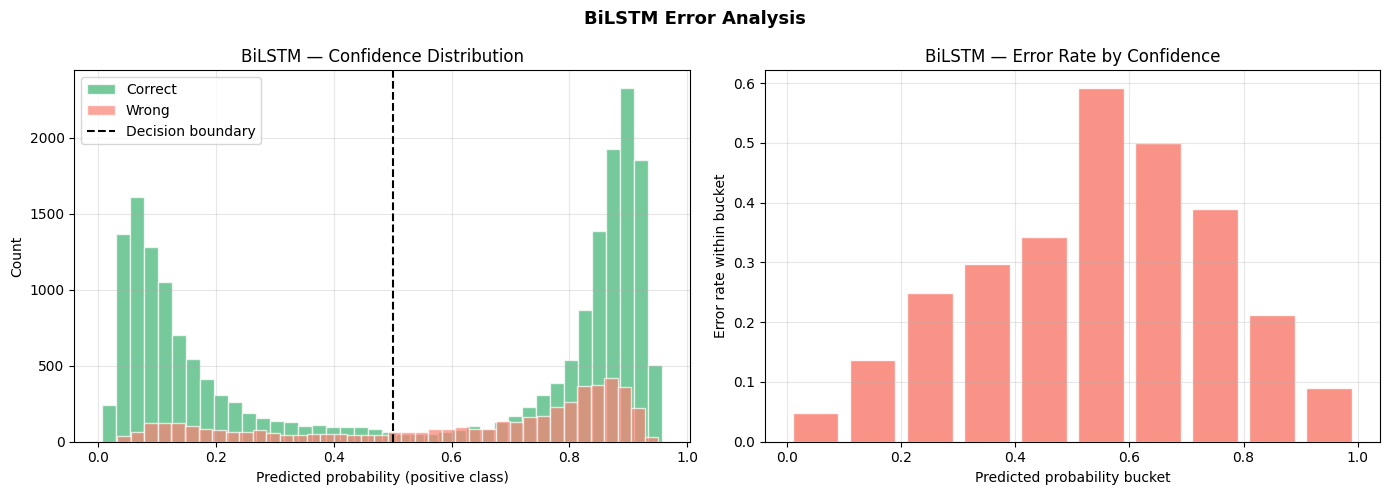


── 10 Misclassified Examples ────────────────────────────────────────

  [0] True=NEG  Pred=POS  Conf=0.862
  Once again Mr. Costner has dragged out a movie for far longer than necessary. Aside from the terrific sea rescue sequences, of which there are very few I just did not care about any of the characters. Most of us have ghosts in the closet, and Costner...

  [3] True=NEG  Pred=POS  Conf=0.790
  Not even the Beatles could write songs everyone liked, and although Walter Hill is no mop-top he's second to none when it comes to thought provoking action movies. The nineties came and social platforms were changing in music and film, the emergence ...

  [6] True=NEG  Pred=POS  Conf=0.820
  This German horror film has to be one of the weirdest I have seen.<br /><br />I was not aware of any connection between child abuse and vampirism, but this is supposed based upon a true character.<br /><br />Our hero is deaf and mute as a result of r...

  [9] True=NEG  Pred=POS  Conf=0.740
  Wealthy

In [ ]:
# ── CELL 10 : Error Analysis ──────────────────────────────────────────────────
# To reload without retraining:
# test_probs = np.load(f"{DRIVE['results']}/test_probs.npy")
# test_preds = np.load(f"{DRIVE['results']}/test_preds.npy")

wrong = np.where(test_preds != test_labels)[0]
right = np.where(test_preds == test_labels)[0]

print(f"Correct : {len(right):,}  ({len(right)/len(test_labels)*100:.1f}%)")
print(f"Wrong   : {len(wrong):,}   ({len(wrong)/len(test_labels)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_probs[right], bins=40, color='mediumseagreen',
             alpha=0.7, label='Correct', edgecolor='white')
axes[0].hist(test_probs[wrong], bins=40, color='salmon',
             alpha=0.7, label='Wrong',   edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--',
                label='Decision boundary')
axes[0].set_xlabel('Predicted probability (positive class)')
axes[0].set_ylabel('Count')
axes[0].set_title('BiLSTM — Confidence Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

buckets = np.linspace(0, 1, 11)
mids, rates = [], []
for lo, hi in zip(buckets[:-1], buckets[1:]):
    mask = (test_probs >= lo) & (test_probs < hi)
    if mask.sum() > 0:
        mids.append((lo + hi) / 2)
        rates.append((test_preds[mask] != test_labels[mask]).mean())

axes[1].bar(mids, rates, width=0.08, color='salmon',
            edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Predicted probability bucket')
axes[1].set_ylabel('Error rate within bucket')
axes[1].set_title('BiLSTM — Error Rate by Confidence')
axes[1].grid(alpha=0.3)

plt.suptitle('BiLSTM Error Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOCAL['plots']}/04_bilstm_error_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("\n── 10 Misclassified Examples ────────────────────────────────────────")
for idx in wrong[:10]:
    true = 'POS' if test_labels[idx] == 1 else 'NEG'
    pred = 'POS' if test_preds[idx]  == 1 else 'NEG'
    conf = test_probs[idx] if test_preds[idx] == 1 else 1 - test_probs[idx]
    print(f"\n  [{idx}] True={true}  Pred={pred}  Conf={conf:.3f}")
    print(f"  {test_texts[idx][:250]}...")